最初に以下のセルを実行

In [1]:
%%capture
!pip install japanize-matplotlib
import japanize_matplotlib
from IPython.display import Markdown, display

In [2]:
NOTEBOOK_TITLE = "01_01 まずは使ってみよう"

import os
from pathlib import Path

OUTPUT_DIR = Path('figures') / NOTEBOOK_TITLE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True, parents=True)

# キャッシュディレクトリを指定
os.environ['TORCH_HOME'] = str(CACHE_DIR)

display(Markdown(f"# {NOTEBOOK_TITLE}"))

# 01_01 まずは使ってみよう

### 日本語テキストの感情分析（文書分類の一種）

In [ ]:
%%capture
!pip install transformers[ja,sentencepiece,torch]

In [50]:
import pandas as pd
from transformers import pipeline
from huggingface_hub import hf_hub_url, get_hf_file_metadata

display(Markdown("### モデルをロード"))
repo_id = "llm-book/bert-base-japanese-v3-marc_ja"
classifier = pipeline(model=repo_id)

display(Markdown("##### モデルのパラメーターのファイルサイズを確認"))
file_size_mb = get_hf_file_metadata(
    hf_hub_url(repo_id=repo_id, filename="pytorch_model.bin")
).size / (1024 * 1024)
print(f"{file_size_mb:.2f} MB")

display(Markdown("### 入力となるテキスト"))
texts = [
    "この製品は素晴らしいです！",  # ポジティブ
    "全然気に入りませんでした。",  # ネガティブ
    "普通かなと思いました。",  # ニュートラル
    "とても楽しい経験でした。",  # ポジティブ
    "サービスが遅くて残念です。",  # ネガティブ
    "まあまあでしたが、期待していたほどではなかった。",  # ニュートラル/ネガティブ
    "この店のラーメンは最高だけど、接客が微妙だった。",  # ポジティブ/ネガティブ
    "映画は素晴らしかったが、座席が硬すぎて痛かった。",  # ポジティブ/ネガティブ
    "前評判は最悪だったが、私は楽しめた。",  # ポジティブ/ネガティブ
]
display(pd.DataFrame({'text': texts}))

display(Markdown("### モデルによる予測を実行"))
predictions = classifier(texts)
display(pd.DataFrame([{'text': t, **p} for t, p in zip(texts, predictions)]))

### モデルをロード

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


##### モデルのパラメーターのファイルサイズを確認

424.29 MB


### 入力となるテキスト

,text
0,この製品は素晴らしいです！
1,全然気に入りませんでした。
2,普通かなと思いました。
3,とても楽しい経験でした。
4,サービスが遅くて残念です。
5,まあまあでしたが、期待していたほどではなかった。
6,この店のラーメンは最高だけど、接客が微妙だった。
7,映画は素晴らしかったが、座席が硬すぎて痛かった。
8,前評判は最悪だったが、私は楽しめた。


### モデルによる予測を実行

,text,label,score
0,この製品は素晴らしいです！,positive,0.999341
1,全然気に入りませんでした。,negative,0.995599
2,普通かなと思いました。,negative,0.844303
3,とても楽しい経験でした。,positive,0.999337
4,サービスが遅くて残念です。,negative,0.966826
5,まあまあでしたが、期待していたほどではなかった。,negative,0.968186
6,この店のラーメンは最高だけど、接客が微妙だった。,negative,0.884773
7,映画は素晴らしかったが、座席が硬すぎて痛かった。,negative,0.876148
8,前評判は最悪だったが、私は楽しめた。,positive,0.999248


### 画像内の物体検出と、検出した物体の分類

In [13]:
%%capture
!pip install ultralytics

### 元の画像

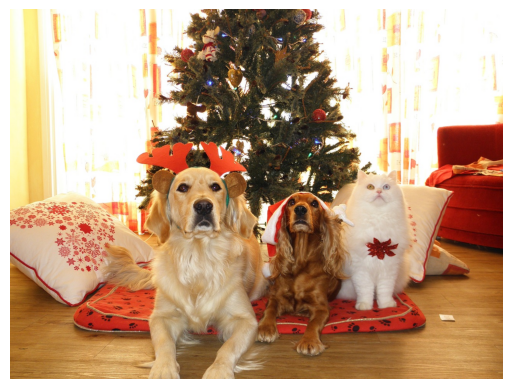

### モデルの読み込み〜実行


0: 480x640 3 dogs, 1 couch, 1 potted plant, 1 bed, 1579.8ms
Speed: 2.5ms preprocess, 1579.8ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)


##### モデルの出力内容

クラス番号: 16, 信頼度: 0.92, 左上座標: (456, 684), 幅: 426px, 高さ: 550px
クラス番号: 16, 信頼度: 0.92, 左上座標: (766, 688), 幅: 250px, 高さ: 427px
クラス番号: 57, 信頼度: 0.90, 左上座標: (1179, 461), 幅: 200px, 高さ: 326px
クラス番号: 16, 信頼度: 0.86, 左上座標: (953, 597), 幅: 184px, 高さ: 375px
クラス番号: 58, 信頼度: 0.31, 左上座標: (636, 276), 幅: 557px, 高さ: 551px
クラス番号: 59, 信頼度: 0.28, 左上座標: (188, 622), 幅: 375px, 高さ: 303px


### モデルの出力内容を元画像に重ねたもの

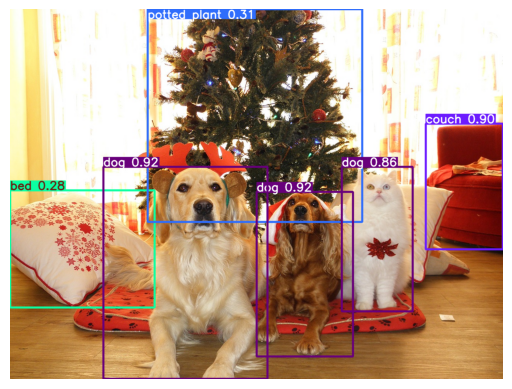

モデルパラメーターのファイルサイズ: 109.33 MB
109.33 MBのモデルで，かなりうまく検出できている


In [ ]:
from IPython.display import Markdown, display
from ultralytics import YOLO
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
import os

# 画像の取得と読み込み
url = 'https://cdn.pixabay.com/photo/2015/09/28/15/01/pets-962215_1280.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)

display(Markdown(f"### 元の画像"))
plt.imshow(img_np)
plt.axis('off')
plt.show()

display(Markdown(f"### モデルの読み込み〜実行"))
# YOLOモデルの読み込み
model = YOLO('yolo11x.pt')
# モデルによる推論
results = model(img_np)

# 推論結果の表示
display(Markdown(f"##### モデルの出力内容"))
for result in results:
    for box in result.boxes:
        x, y, w, h = box.xywh[0]
        print(f"クラス番号: {int(box.cls.item())}, 信頼度: {box.conf.item():.2f}, 左上座標: ({x:.0f}, {y:.0f}), 幅: {w:.0f}px, 高さ: {h:.0f}px")

# 検出結果を画像に重ねて表示
display(Markdown(f"### モデルの出力内容を元画像に重ねたもの"))
annotated_img = results[0].plot()
plt.imshow(annotated_img)
plt.axis('off')
plt.show()

# モデルファイルのサイズを表示
model_size = os.path.getsize('yolo11x.pt') / (1024 * 1024)  # MB単位に変換
print(f"モデルパラメーターのファイルサイズ: {model_size:.2f} MB")

print(f"{model_size:.2f} MBのモデルで，かなりうまく検出できている")

### 画像内人物の姿勢推定

In [ ]:
%%capture
!pip install ultralytics

### 元の画像

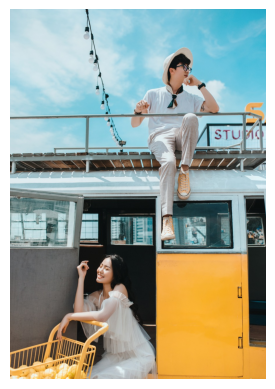

### モデルの読み込み〜実行


0: 640x448 2 persons, 1617.2ms
Speed: 6.2ms preprocess, 1617.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)


##### モデルの出力内容

,result_id,person_id,name,x,y,confidence
0,0,0,鼻,608.968018,211.149628,0.979946
1,0,0,左目,617.014160,202.383545,0.687656
2,0,0,右目,597.218689,199.049622,0.982599
3,0,0,左耳,0.000000,0.000000,0.093852
4,0,0,右耳,558.177734,214.029419,0.981570
5,0,0,左肩,611.060974,294.791656,0.995519
6,0,0,右肩,490.368286,311.518799,0.985542
7,0,0,左肘,695.929810,359.464111,0.983718
8,0,0,右肘,430.587585,394.231079,0.979271
9,0,0,左手首,658.131042,257.699097,0.982407


### ポーズ推定結果（元画像なし）

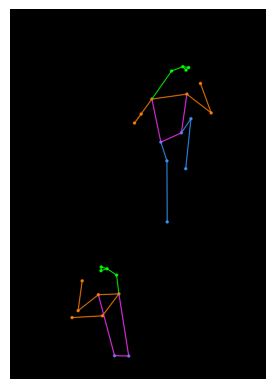

### ポーズ推定結果（画像に重ねてプロット）

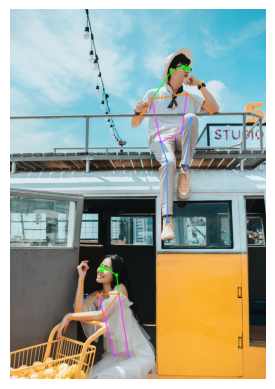

モデルパラメーターのファイルサイズ: 112.99 MB
112.99 MBのモデルで，かなりうまく検出できている


In [ ]:
from IPython.display import Markdown, display
from ultralytics import YOLO
from PIL import Image
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

# 画像の取得と読み込み
url = "https://cdn.pixabay.com/photo/2019/06/22/18/30/woman-4292200_1280.jpg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)

display(Markdown(f"### 元の画像"))
plt.imshow(img_np)
plt.axis('off')
plt.show()

display(Markdown(f"### モデルの読み込み〜実行"))
# YOLO11ポーズモデルの読み込み
model_name = 'yolo11x-pose.pt'
model = YOLO(model_name)
# モデルによる推論
results = model(img_np)

# 推論結果の表示
display(Markdown(f"##### モデルの出力内容"))
keypoint_names = ["鼻", "左目", "右目", "左耳", "右耳", "左肩", "右肩", "左肘", "右肘", "左手首", "右手首", "左腰", "右腰", "左膝", "右膝", "左足首", "右足首"]
results_df = pd.DataFrame([
    {'result_id': result_id, 'person_id': person_id, 'name': keypoint_names[keypoint_id], 'x': xyconf[0], 'y': xyconf[1], 'confidence': xyconf[2]}
    for result_id, result in enumerate(results)
    for person_id, keypoints in enumerate(result.keypoints)
    for keypoint_id, xyconf in enumerate(keypoints.data[0].numpy())
])
display(results_df)

# ポーズのみを新しいキャンバスに描画
display(Markdown(f"### ポーズ推定結果（元画像なし）"))
pose_img = results[0].plot(boxes=False, masks=False, img=np.zeros_like(img_np))
plt.imshow(pose_img)
plt.axis('off')
plt.show()

# ポーズのみを新しいキャンバスに描画
display(Markdown(f"### ポーズ推定結果（画像に重ねてプロット）"))
pose_img = results[0].plot(boxes=False)
plt.imshow(pose_img)
plt.axis('off')
plt.show()


# モデルファイルのサイズを表示
model_size = os.path.getsize(model_name) / (1024 * 1024)  # MB単位に変換
print(f"モデルパラメーターのファイルサイズ: {model_size:.2f} MB")

print(f"{model_size:.2f} MBのモデルで，かなりうまく検出できている")

### 画像のセグメンテーション

In [161]:
%%capture
!pip install ultralytics matplotlib pillow requests opencv-python


0: 640x448 2 persons, 209.2ms
Speed: 3.1ms preprocess, 209.2ms inference, 29.8ms postprocess per image at shape (1, 3, 640, 448)


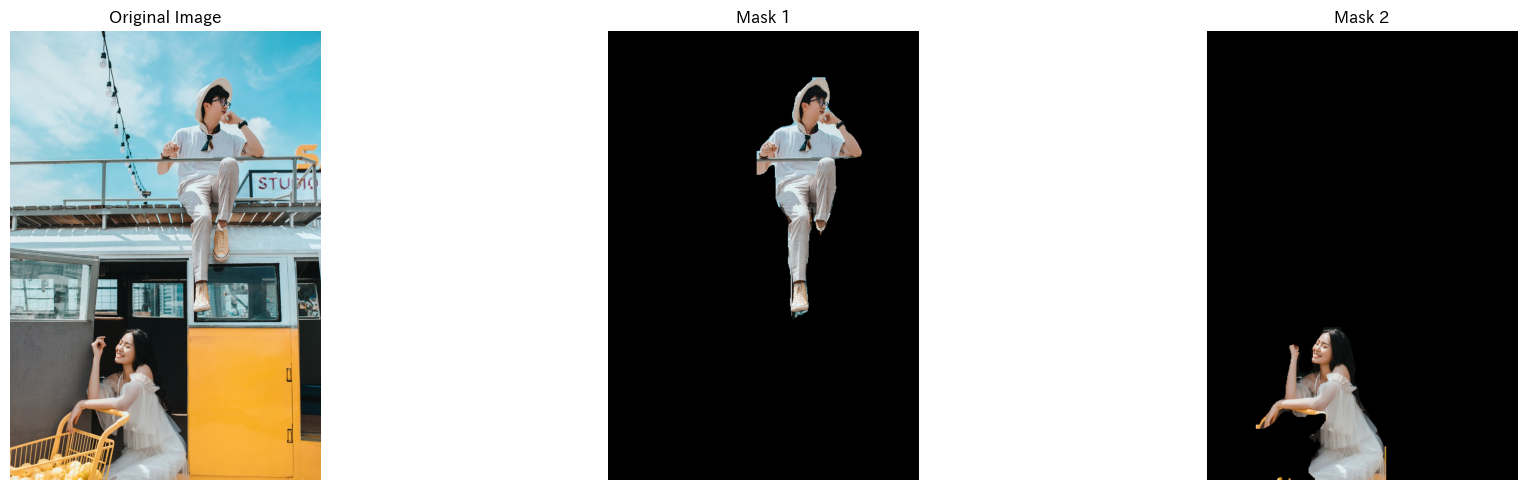

In [160]:
# Import necessary modules
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import cv2  # For resizing masks

# Load the YOLO11-seg pretrained model
model = YOLO("yolo11n-seg.pt")  # Replace 'yolo11n-seg.pt' with any other variant like yolo11x-seg.pt for higher accuracy

# Load and preprocess the image
url = "https://cdn.pixabay.com/photo/2019/06/22/18/30/woman-4292200_1280.jpg"
img = np.array(Image.open(BytesIO(requests.get(url).content)).convert("RGB"))

# Predict segmentation masks
results = model(img)

# Extract masks and visualize them
fig, ax = plt.subplots(1, len(results[0].masks.data) + 1, figsize=(20, 5))

# Show original image
ax[0].imshow(img)
ax[0].axis('off')
ax[0].set_title('Original Image')

# Display each mask overlaid on the original image
for i, mask in enumerate(results[0].masks.data.cpu().numpy()):
    # Resize the mask to match the original image size
    resized_mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    # Apply the mask to isolate the object
    mask_img = img.copy()
    mask_img[resized_mask == 0] = 0
    ax[i + 1].imshow(mask_img)
    ax[i + 1].axis('off')
    ax[i + 1].set_title(f'Mask {i + 1}')

plt.tight_layout()
plt.show()

### 手書き数字画像のクラスタリング

In [129]:
%%capture
!pip install scikit-learn matplotlib numpy

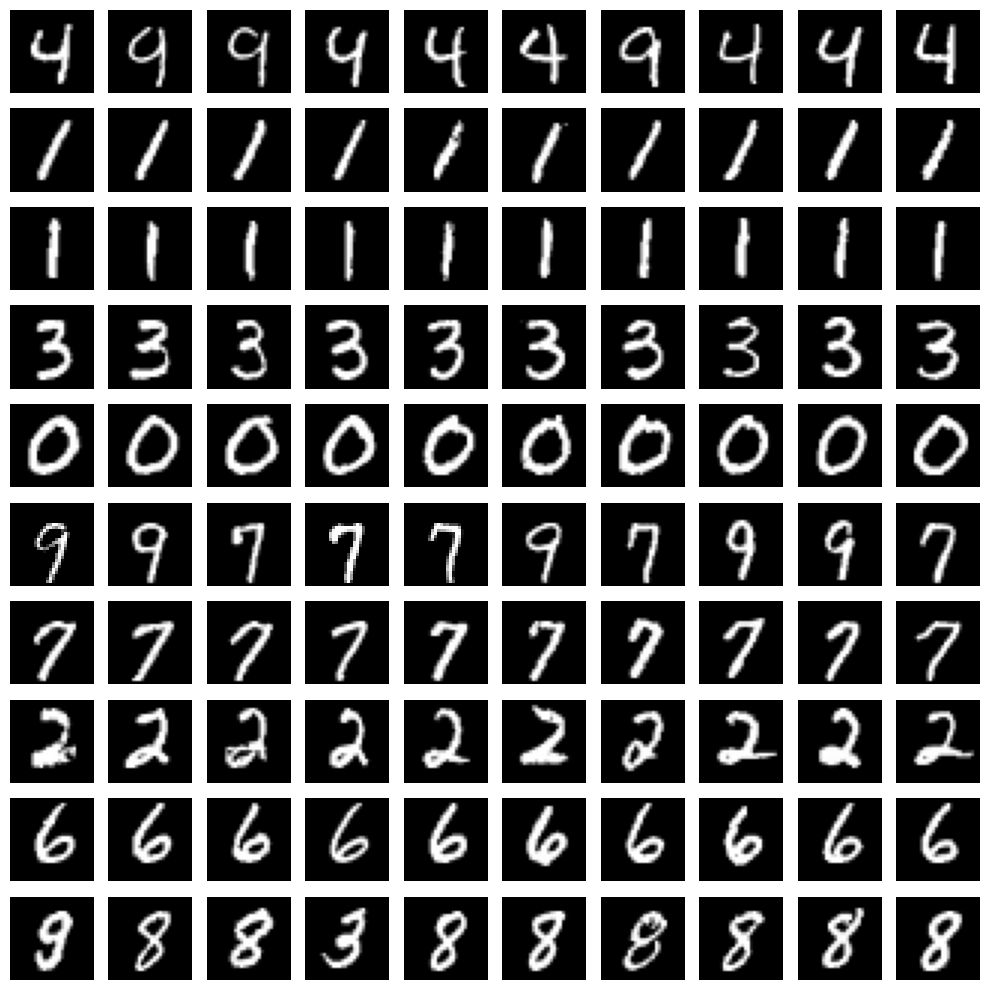

### 結果

画像と数字の対応関係を教えたりすることなく，似ている画像を自然にまとめることができた


In [130]:
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np

# MNIST データセットのロード
X = fetch_openml("mnist_784", version=1)["data"].to_numpy()  # Convert to NumPy array

# K-means クラスタリングの適用
kmeans = KMeans(n_clusters=10, random_state=42, n_init="auto").fit(X)
clusters = kmeans.labels_

# クラスタごとにクラスタ中心に最も近い10個のサンプルを選択
def closest_samples(cluster_label, n_samples=10):
    cluster_indices = np.where(clusters == cluster_label)[0]
    center = kmeans.cluster_centers_[cluster_label]
    distances = np.linalg.norm(X[cluster_indices] - center, axis=1)
    closest_idxs = cluster_indices[np.argsort(distances)[:n_samples]]
    return X[closest_idxs].reshape(-1, 28, 28)

# 各クラスタの10個の画像を可視化
fig, axes = plt.subplots(10, 10, figsize=(10, 10))  # 10 clusters, 10 images each
for cluster_label in range(10):
    images = closest_samples(cluster_label)
    for i, ax in enumerate(axes[cluster_label]):
        ax.imshow(images[i], cmap="gray")
        ax.axis("off")

plt.tight_layout()
plt.show()

display(Markdown("### 結果"))
print("画像と数字の対応関係を教えたりすることなく，似ている画像を自然にまとめることができた")

### 音声合成

In [13]:
%%capture
!pip install tokenizers==0.13.3 transformers==4.33.3
!pip install git+https://github.com/myshell-ai/MeloTTS.git

In [18]:
from melo.api import TTS

# Initialize the TTS model for Japanese
text = "彼は毎朝ジョギングをして体を健康に保っています。"
model = TTS(language='JP', device='cpu')  # Correct identifier for Japanese

# Generate and save the audio
output_path = OUTPUT_DIR / 'japanese_output.wav'
speaker_ids = model.hps.data.spk2id
model.tts_to_file(text, speaker_ids['JP'], output_path, speed=1.0)

# Play the audio
from IPython.display import Audio
display(Markdown("#### 合成された音声"))
Audio(output_path)

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


 > Text split to sentences.
彼は毎朝ジョギングをして体を健康に保っています.
 > ===========================


100%|██████████| 1/1 [00:03<00:00,  3.88s/it]


#### 合成された音声

### OCR

次のコードによって、予め画像を文字列にエンコードしてある．その文字列が次のセルで読み込まれている．
```python
from PIL import Image
import base64
from io import BytesIO

# 画像を読み込む
image = Image.open("スケッチ.png")

# RGBに変換
image.load() # required for png.split()
background = Image.new("RGB", image.size, (255, 255, 255))
background.paste(image, mask=image.split()[3]) # 3 is the alpha channel
background.save('foo.jpg', 'JPEG', quality=80)

# 圧縮サイズを指定（例: 長辺を50ピクセルに縮小）
# max_size = 100
# background.thumbnail((max_size, max_size))

display(background)

# 圧縮した画像をメモリ上に保存
buffer = BytesIO()
background.save(buffer, format="JPEG")  # 必要に応じてフォーマットを変更可能

# Base64エンコード
encoded_string = base64.b64encode(buffer.getvalue()).decode('utf-8')

# エンコードされた文字列を表示
print(encoded_string)
```

In [ ]:
%%capture
!pip install easyocr pillow

## 読み込ませる画像

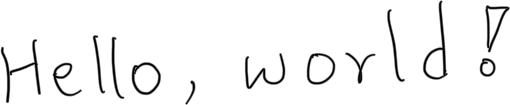

['Hello,', 'woxld']


In [ ]:
import base64
from PIL import Image
from io import BytesIO

# Base64エンコードされた文字列をデコードして画像データを取得
image_data = base64.b64decode('/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBwcJCQgKDBQNDAsLDBkSEw8UHRofHh0aHBwgJC4nICIsIxwcKDcpLDAxNDQ0Hyc5PTgyPC4zNDL/2wBDAQkJCQwLDBgNDRgyIRwhMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjIyMjL/wAARCABpAf4DASIAAhEBAxEB/8QAHwAAAQUBAQEBAQEAAAAAAAAAAAECAwQFBgcICQoL/8QAtRAAAgEDAwIEAwUFBAQAAAF9AQIDAAQRBRIhMUEGE1FhByJxFDKBkaEII0KxwRVS0fAkM2JyggkKFhcYGRolJicoKSo0NTY3ODk6Q0RFRkdISUpTVFVWV1hZWmNkZWZnaGlqc3R1dnd4eXqDhIWGh4iJipKTlJWWl5iZmqKjpKWmp6ipqrKztLW2t7i5usLDxMXGx8jJytLT1NXW19jZ2uHi4+Tl5ufo6erx8vP09fb3+Pn6/8QAHwEAAwEBAQEBAQEBAQAAAAAAAAECAwQFBgcICQoL/8QAtREAAgECBAQDBAcFBAQAAQJ3AAECAxEEBSExBhJBUQdhcRMiMoEIFEKRobHBCSMzUvAVYnLRChYkNOEl8RcYGRomJygpKjU2Nzg5OkNERUZHSElKU1RVVldYWVpjZGVmZ2hpanN0dXZ3eHl6goOEhYaHiImKkpOUlZaXmJmaoqOkpaanqKmqsrO0tba3uLm6wsPExcbHyMnK0tPU1dbX2Nna4uPk5ebn6Onq8vP09fb3+Pn6/9oADAMBAAIRAxEAPwD3+iiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiuD8V6pqc3xC8N+GrK/ksbe5SS7uJIQN7iPomT0BxzXeUAFFFFABRRRQBj+K9Qm0nwlq2oW5xPb2kkkZPZgpxWZ8NTK/wAPNGnnuZrie4g8+SSZyzFmJJ69uelaXi62+1+Ddatx1kspgP8Avg1h/CS5F18LdBYHOyAxn/gLEf0oA7WiiigAooooAztd1yx8OaNcarqMjJawAFiq7mOTgADucmsi0+I/g68tY7iPxFp6q65CyTBGHsQeQay/jJDLJ8MtSkiJ/cNFM6j+JVcZB9qv2ngrwfrFlbak/hzTXa6iSYt5C87gD/WgB8nxL8FRHDeJtOz7TA/yq9pXjLw3rcjx6brdlcug3MqSjIHrzWJ4n0zwd4N8L3uryeHtL226fIn2ZMu54Venc1lfDn4fw29mfEOu28cmrakm8wBAsdtGxDBFQcDoM0AemUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQB5r4tY2Pxm8FXjj91PFcWmf9ojI/nXpVebfGeJ7bw7pevxZ83R9RhuMjspOG/pXosEyXFvFPGcpIgdT6gjIoAkooooAKKKKAIL2Lz7G4hP8Ay0iZfzGK88+BkhPw4SAnm2vJ4semGz/WvSq8t+CxMNt4p08/8uuszAD0B/8A1UAepUUUUAFFFFAHO+PbcXXgDX4SMhrGX9FJ/pUPw4uDdfDjw/KxyTZRg/gMf0rR8VDd4R1ketjN/wCgGsP4WyLH8KdBkkYKiWmWJ7AE0AYfjj/iqfiR4c8Iqd1pbE6lfqOhC/cU/U/zr08DAwOleY/CxG17WPEnjWZT/wATC6NvaE9oI+Bj6nH5V6dQAUVBBeWtzLPFBcRSyQNslRHBMbdcMB0NT0AFFFFAES3Nu9w9uk8TTIMtGHBZR6kdalry/wCDtrbXMGva3LEr6nNqlxDJcNy5QMCF+leoUAFFFFABRRRQAVynxA8W3Hg7QIb+1s47maa6jtlWVyqKW7sR24rq64r4tab/AGn8MtZQDMkMQuEx2ZCG/kDQB0+jT6jc6VBNqtpFaXrA+bDFL5irzxhu/GKuswRGdjhVGSaxvCGp/wBs+DtH1DOTPaRsx99oB/XNa1x/x7S/7h/lQBz3hLxxpfjNbltNju0FucEzwlQwyRlT0PINdLXmvwMOfh37fbrjH/fVelUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAFFFFAGB420oa34I1nTyMma0fb/vAZH6gVmfCvVzrPw20a4dt0scPkSE/3kO3+QFdiyhlKkZBGCK8v+DDNZ2/ifQ24Gn6tIEHordP5UAeo0UUUAFFFFABXlvw4P2T4k/EDThwPtiTgf72f8a9PlljhQvLIsaDqzHAry7wvJEnx78VLDIjx3NhDKGQ5BxtHX86APVKKKKACiiigDJ8UEDwnrGen2Kb/wBANeTSa3cad8BvDej6eSdU1qJbO3VeoDMdzfkf1r1PxosreCNcWEEyGxm2gf7hryb4WWv/AAkninTbtxvsPDekwQQAjjz5EDMfqMn8qAPYPDeiQeHPDlhpFuP3drCqZ/vHufxOTWrRRQB5h8P7j+zfiP420S9yt7cXYvoS3/LSIjgj6ZFen15X8Uoz4d8SeGvG1uCptrkWd4Rxuhf1/WvU1YOoZTlSMgjvQAtFFRXFzBaQNPczRwxLyzyMFUfiaAPNfhN/oOteNtGY822rNKo/2Xz/AIV6fXkPgrV9Nn+OPicabfQXNtqFpHMrxOCC64DD69a9eoAKKKiuLmC0haa5mjhiX7zyMFUfiaAJaKx7TxX4ev7kW1prenzzk4EcdwpYn2Ga2KACqWr2ovtFvrRhkT28kePqpFXaKAPPPgndtcfDKxhc/PaSy259trn/ABru747dPuT6RMf0Neb/AAdzaS+LtJPAs9YkKj0Df/qr0i+BbT7kDqYmH6GgDz74Ff8AJMrc+t1OT/33XpNea/Ao/wDFsoB3W6nB/wC+69KoAKKKq6hqdjpNo11qF3DawL1kmcKP1oAtUVzNn8RPB1/crb23iPT3lY4C+aBk/jXSghgCCCDyCO9AC0UUUAFFFFABRRRQAUUUUAFFFFABRXA/GDULqx8ErFaTvA97ew2rvGcMEdvmAP0FdvZWsdjYwWkW7y4I1jXcxY4AwMk9aAJ6KKKAI55lt7eWd87I0LtgZOAM1T0PWrPxDo1tqunuzWtyu5CwweuMEdjxV9gGUqRkEYIrzn4Tu1h/wknhqQ86Vqcnlj/pnJ8y/h1oA9HooooAiurmCytZbq5lWKCJS8kjnAUDqTXAN8avCLXSW9odQvXfJX7NZs27Gc46E9D0pvxYnlv4dC8JwOVbW75Y5sHnyU+Z/wCldnpvh7StJsbKztLKJYrJdtuWXcye4Y855PNAGBpvxT8JajdLanUWs7hjhYr6JoCT/wACGP1rsVZXUMpBUjIIPBrP1fQdK160e11Swt7uJhgiVASPoeorhNHe9+Hfi608NXNzLdeHdUZl02WU5e2lHPlE9we1AHplcdffEfS9I8SnR9YtL7Tld9kF7cRYt5j7Nnj8a7GqOr6Pp+vabLp+p2sdzbSjDI4z+I9D70AXVZXQOjBlYZBByCKGYKpZiAAMkntXl2gXV98OPFVv4U1S5kudA1AkaTdynLQv/wA8WP8AKrHi26uvGXjKHwPYXEkOnwRi41ieI4Ow/diB7Z70AdC3xG8KjVU02LVUuLppBFtt42lCsTgAsoIFdTVDSdE0zQ7KOz0yyhtYEGAsaAfme5q/QAV5d4FzafGDx7ZdFkaG5A+o/wDr16jXmOnH7L+0PrEY4F3pEcn1IIH9KAPTqKKKACuL8deN5PDrWuk6Ra/b/EOoHba2w6KP77+wrspJFhieRzhEUsx9AK8u+Flu3iTWNb8e3o3zXlw1tY7ufKgQ44+v9KAJbT4VT64wvvHWtXeq3Tc/ZIpDHbxewA61keHdB07wp8f5dM0m3+z2cuj7xHvLc7hnqfavZa8tvx5X7R2lN/z10eQfkW/woA9SooooAKKKKAEYblI9RjpXM+B/CA8IaZdwSXX2u6u7uS6mn2bdxY8DGewrz7xd8SNcg8dXmj6NrFhbW9t5ca7rN7jfIR8wYqDtweK6nw/421i38RQ+GvGWnw2Wo3ClrS6t2JgucdQM9G9qAO/ooooA4j4vWIv/AIXa2pGWiiEy/VWB/wAazbT4seGdH8LaN/aF60uoSWULG1t4zJJkoOoHTPvXWeNIRceB9ciPRrGb/wBANcV8F/DOnweFLXxDjzLu/gjVhIikR+XlBtOMjIAzz2oAD468ceJv3fhbwjJZQv0vtWOwD3C9/wBasWnwsn1e4W98c65ca3MDlbRCY7ZPbaOv6V6VRQB5HNpdhoHx/wBBis7SC3tp9KkjjjjQBVI3dPf/ABr1yvLPiEPsfxW8A6jnCtPJbMf97H+Nep0AZHifxBbeFvDd7rN2C0dtHu2Dq7dAo+pIrgtF8D6h44EOv+PLmSWOYCW20eJysMKHkbgPvHFWfjtBcS/DWaWGQrHDcxSTIB99d2ME9sEg/hVbS/H3iq20i1th8PtVuHWFVjmS5WRJBjht+OQeuaAKvxR8L+GdI8N2lvpOjWdtrF3eQwWLW8YWQNuBJBHPAr1uJWSFFdtzBQCfU1wPhjwlrGoeIF8W+MnjbUkUrZWMRzHZqf5t716DQAUUUUAeYeBSbX4u+PbLoJHhuAPqP/r16cyh0KnoRivM9GxbftBeIo+n2nS4ZPrgqK9NoA8w+Bz7PDGr2Xe11adMenSvT68u+FYFl4s8eaX08rVPOUezZ/8ArV6jQB5t8ZfFN34f0CxtbC6ltZ7+42vPD/rI4kG5yvviqHhH4cXGu2trrXjy5uNUnKBrWyuZdyQIem8AAM/qaPijZQan8QvAlheIXtZriZXXJGeB3FesAAAADAFAHLah8N/B+p2jW0/h+xVSMBoYhGy+4I5rkdBu9Q+GviuDwtq91LdeH9QbGlXkxyYX/wCeTH+Ver1wHxmtoJvhlqU8oxLamOaB+6SBwAQfxoA7+iqOizS3GhafNMSZZLaN3J7sVBNXqACiiigAooooAKKKKACiiigDzb41ceE9MP8A1F7b+Zr0mvOPjgp/4VzJOOtveQSj2w+P613Fxqtrp2hNqt7MsVtFAJpHPYYzQBj+OPG1j4I0dbu5ja4uZW2W9qjYaVu/0AHJNavh/V01/wAPafq8cZiS8gWYITkrkdM15VZaNqHjyw13xtqcLgzWM8GiWjf8s4ipG/H95v612nwov7e++GmiiCQM1vAIJV7o68EGgDs6810r/QPj7rlvHxHfaVFcOP8AaUhc16USAMngV5l4TmTxB8YfEuu2p8yxs7aPT45l5V3By2D3xigD02iiigDzbWMXnx78PQNytnpc04H+0xK5r0mvNdUZbL4/6LNOwSO70mWCJj3cMTj616VQAV5z8UGE+seCrGPBnl1lJFA6hUGSf1rtdb13TfDumS6jqt3Hb20YyWY8sfQDufauE8IWeoeMvFv/AAnWrWz2tjDGYdHtJB8wQ9ZWHqaAPTKKKKAOO+KGiJrfgLUMEJc2afa7aXOCkkfzA5+gIrK+DtpJP4bu/Et3817rl09y7HkhASFH4YNXvi9fPYfC/WXjOHljWEH03sAf0Jqv8FWLfC/TgeiyTKPoJGoA9AooooAK8x1UCx/aE0ScnC32lSw/UqSf8K9OrzP4swzaZP4d8YW8TSDRbzNyFGT5L8Mfw/rQB6ZRWdpmvaTrKI2nahbXJaIShYpAzBD0JA5FaNAGb4iEh8M6qIgTIbOXaB1zsNcp8GXhb4V6OIWU7VcPjs285BrvCAQQQCD1Brymbw/4n+HOt3eoeE7MatoN5IZZ9K3Ykhc9TH/hQB6vXlXiKZLf9oTwsXJHmafLGMAnJO/FaEHxesGHl3PhzxFBddPI+wMxz6ZFUF8M67438aWHim/gn8PWtlF5cMQkBuZV3Z5xwmeQevBoA9UooooAKbKWWJyoywUkfWnUUAebfBOOJ/BU90yqbufULh7hiPm3bu/4Uvxa2SHwrDDg6i2tQm3A+9gfeI9sYp978PdY0zW7vU/BfiBdKF6/mXNnPD5sLP3YDsau+HfAd3ba8PEXifVzrGsIpSAiPZFbqeuxfU+tAHcUUUUAZHir/kUNZ/68Zv8A0A1zfwc/5JVon+4//obVueOLgWvgXXZieFsZv/QSKyvhLCYPhboCnq1uX/Nif60AdpRRRQB5b8bVNvpfh3Vl4+w6vE5PoD/+qvUVYMoYcgjIrivizoN54i+Ht9Z6fA094rxyxRp1Yqw4H4Zrq9L87+yLL7Qhjn8hPMQ9VbaMj86AK/iLRofEPh3UNJn+5dwNHn0JHB/A4Ncb8IddlufDsvhzUTs1bQ5DazI3UoD8rfTHH4V6LXm/jXwrrFh4kh8beEY1k1ONfLvbInAu4/8A4r/61AHpFFec2Xxo8Nsgj1aK/wBKvV4kt7i1clT7EDmpn8aaz4pBtvBukTLE3ynVdQjMUMfuqH5nNAHoFFVNLtbiy0u2tru8e8uI0CyXDqFMh9SBxVugDzO/X+z/ANoPS52OE1DSJIgfVkYnFemVxnjvwvqWsXGjaxoTwLq+k3HmRCckJIjDDKSK6yyFytjAL1o2uhGvnNECFL45wD2zQB5rouNJ/aA1+0PC6pp8dynuy4B/rXqNeY/EpG8P+KvDPjZVb7PZym0vio6QycZPsCTXpcM0dxCk0LrJFIoZHU5DA9CKAPN/jJZXMOkaV4nskLz6FercsFHJjJAb+Qrv9K1O21nSrXUrOQSW9zGJEYHsRU9zbw3dtLbXEayQyqUdGGQwPBBryeHRPGfwyvJ4/DVmNe8OSuZEsmk2zW5PUKe4oA9dryz4m3x8U6vp3w/0w+bPcTpPqLryIIFOefc/4Ulz41+IOuxfYNG8E3Gl3MvyteX0g2Qj1AwMmun8DeB4PCFpPLNcNfaveN5l7fSfekb0HoooA6qKNYYUiQYRFCqPQCn0UUAFUNb0+TVtEvdPiupLWS4haNZ4jhoyRwRV+s7XtXg0DQb7VblgIrWFpDnuQOB+JwKAON+D2sahqXha7tNTuXurjTL6Wz89zlnVcYya9Drh/hRok+keCo57xNl5qUz30yn+EyHIH5YruKACiiigAooooA4r4t2L6h8L9biiQu6QiUADJ+VgT+gNcRFqEnxZutH8PWLuPD1hbwTarOuQJpNoIhB+vX8a9rZVdSrKGVhggjIIqvZafZabCYbG0gtoydxSGMICfXAoAmhhjt4I4YUVIo1CoijAUDoBXn+p/DO4t9XuNX8Ia9PoV1ctvngVBJBK3qUPSvQ6KAPNJfAvjjWk+y6/44/0BuJY9PthE8g9C3au50LQdO8N6TDpmlW6wW0Q4Uclj3JPcn1rSooAKKKKAOd8X+DrHxhp8UFzJLbXVu/m2t3AcSQv6j/CuXXwp8TYF8mHx5ayQjgPNYgyY9z616VRQB57pfwsgfUo9U8VavdeIb6M5jFz8sMZ9kHFeggBVCqAABgAdqWigAooooAxfFnhq38XeG7rRbqV4Y7gL+8QZKkEEEZ+lT+HdCtPDWgWej2O7yLVNilurHqSfcnJrTooAKKKKACo5oYrmB4Z41kicFXRxkMPQipKKAMbRPCeg+G3mfR9Lt7N5/8AWNEvJ9vp7Vs0UUAFFFFABRRRQAUUUUAFFFFABRRRQAUUUUAcr8SbO91D4d63Z6dbyXF1NBsSKMZZskZx+Ga0PCGnyaV4O0ewmjMcsFnGjoeqttGR+dbVFABRRRQAUUUUAFFFFAEbwQynMkSOR3ZQakAAGAMCiigAooooAKKKKAIL2yttSsprO8gSe2mUpJG4yGBrH8M+EdP8JpPFps16YJcYhnuGkSIDPCA9Otb9FABRRRQAUUUUAFFFFABXn2vBvHPjCPw3Fk6NpUi3GqOOksvVIf6mvQazNM/4/wDVP+vgf+gLQBpABQAAABwAKWiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooAKKKKACiiigAooooA//9k=')
image = Image.open(BytesIO(image_data)).convert("RGB")
display(Markdown('## 読み込ませる画像'))
display(image)

import easyocr
temp_file = CACHE_DIR / 'ocr_image.jpg'
image.save(temp_file, format='JPEG')

reader = easyocr.Reader(['en', 'ja'])
result = reader.readtext(str(temp_file), detail=0)
print(result)

### 音声の文字起こし

In [ ]:
%%capture
# 必要なライブラリをインストール
!pip install soundfile ffmpeg-python
!git clone https://github.com/reazon-research/reazonspeech  # ReazonSpeechリポジトリをクローン
!pip install --no-warn-conflicts reazonspeech/pkg/nemo-asr  # ReazonSpeech用ライブラリのインストール
# サンプル音声をダウンロード
!cd cache/; curl -O https://research.reazon.jp/_static/demo.mp3 

In [13]:
from IPython.display import Audio, display

# サンプル音声
display(Markdown("### 文字起こし対象のデモ音声"))
test_file_path = "cache/demo.mp3"
display(Audio(test_file_path))

# ReazonSpeechを使用した音声認識のデモ
from reazonspeech.nemo.asr import transcribe, audio_from_path, load_model

# モデルのロード
model = load_model()

def transcribe_audio(file_path):
    """音声ファイルをReazonSpeechを用いて文字起こしする"""
    audio = audio_from_path(file_path)
    result = transcribe(model, audio)
    return result

def display_transcription(result):
    """音声認識の結果を表示する"""
    for seg in result.segments:
        print(f"{seg.start_seconds:.2f} - {seg.end_seconds:.2f}: {seg.text}")

# テスト用の音声ファイル
result = transcribe_audio(test_file_path)

display(Markdown("### 音声認識結果"))
display_transcription(result)

### 文字起こし対象のデモ音声

Transcribing:   0%|          | 0/1 [00:00<?, ?it/s]

Beam search progress:: 100%|██████████| 1/1 [00:01<00:00,  1.74s/sample]


### 音声認識結果

0.46 - 3.90: 長野県は全国で3番目に大きな県です。
4.46 - 7.58: お隣の山梨県の3倍以上もあります。
8.70 - 15.98: 長野から飯田へ行くのにも東京へ行くのと同じ時間がかかるのを見ても面積の広いことが分かります。


### CIFAR-10 データセットを用いた画像分類 (WIP)

Files already downloaded and verified


/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


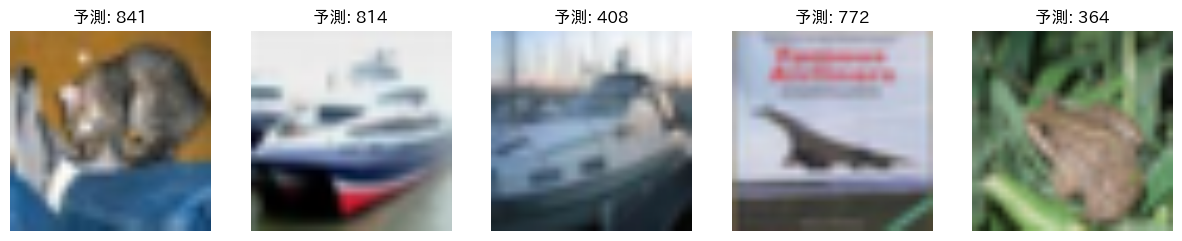

In [18]:
!pip install torch torchvision matplotlib

from torchvision import models, transforms, datasets
import torch
import matplotlib.pyplot as plt

# CIFAR-10データセットと事前学習済みのResNetモデルをロード
transform = transforms.Compose([transforms.Resize(224), transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
dataset = datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)
model = models.resnet18(pretrained=True).eval()

# サンプル画像と予測ラベルを表示
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, (img, _) in enumerate([dataset[i] for i in range(5)]):
    img_t = img.unsqueeze(0)
    with torch.no_grad():
        outputs = model(img_t)
        _, predicted_class = outputs.max(1)
    
    # 画像と予測のプロット
    img_display = img.permute(1, 2, 0) * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
    axes[i].imshow(img_display.numpy().clip(0, 1))
    axes[i].set_title(f"予測: {predicted_class.item()}")
    axes[i].axis("off")
plt.show()

### 航空旅客データセットによる時系列予測 (WIP)

In [ ]:
from fbprophet import Prophet
import pandas as pd

# 航空旅客データセットのロード
data_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(data_url)
data.columns = ["ds", "y"]  # Prophetに合わせた列名に変更

# Prophetモデルの初期化と学習
model = Prophet()
model.fit(data)

# 次の30ヶ月を予測
future = model.make_future_dataframe(periods=30, freq="M")
forecast = model.predict(future)

# 予測結果のプロット
fig = model.plot(forecast)
plt.title("航空旅客の予測")
plt.show()

### GPT-2 を使用したテキスト生成 (WIP)

In [131]:
from transformers import pipeline

# GPT-2 によるテキスト生成パイプラインのロード
generator = pipeline("text-generation", model="gpt2")

# 提示文に基づくテキスト生成
prompt = "未来のある日、"
generated_text = generator(prompt, max_length=50, num_return_sequences=1)[0]["generated_text"]
print(generated_text)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_to

未来のある日、どこするにその御塚が言うち発ゃないことのよう

と、ち


### 多様体学習（非線形次元削減）

In [17]:
%%capture
!pip install umap-learn

In [16]:
from sklearn.datasets import fetch_openml
from umap import UMAP
import matplotlib.pyplot as plt

# Fashion MNIST データセットのロード
fashion_mnist = fetch_openml("Fashion-MNIST", version=1)
X, y = fashion_mnist.data, fashion_mnist.target

# UMAP による次元削減の適用
umap = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_reduced = umap.fit_transform(X)

# UMAP 結果のプロット
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y.astype(int), cmap="Spectral", s=1)
plt.colorbar(scatter)
plt.title("Fashion MNIST の UMAP 表現")
plt.show()

/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


SystemError: CPUDispatcher(<function nn_descent at 0x153881440>) returned a result with an exception set

### 植物画像の分類

In [20]:
# 必要なライブラリのインポート
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import os
from PIL import Image
import requests
from io import BytesIO

# データ変換の定義
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# iNaturalist 2021 mini評価データセットのロード
dataset = datasets.INaturalist(root='./data', version='2021_valid', transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# iNaturalist用に学習された事前学習済みResNet-50モデルの取得
model = models.resnet50(pretrained=False)
checkpoint = torch.hub.load_state_dict_from_url(
    'https://ml-inat-competition-datasets.s3.amazonaws.com/2017/models/resnet50_inat2017.tar.gz',
    map_location='cpu'
)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

# クラスインデックスからクラス名へのマッピングをロード
labels_map_path = os.path.join(dataset.root, '2021_valid', 'labels.json')
with open(labels_map_path) as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}

# 画像と予測結果を表示する関数
def imshow(img, title):
    img = img / 2 + 0.5  # 正規化を元に戻す
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# バッチから画像を取得し、予測を行う
dataiter = iter(dataloader)
images, labels = dataiter.next()

# モデルで予測
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# 画像と予測結果を表示
for i in range(5):  # 最初の5枚の画像を表示
    imshow(images[i], f'予測: {idx_to_class[predicted[i].item()]}\n実際: {idx_to_class[labels[i].item()]}')

  0%|          | 327680/8931661582 [00:10<78:45:09, 31502.78it/s] 


KeyboardInterrupt: 